**Copied code from the data_loading file to display the projection on the map and the data points for the stations.**


In [1]:
from pathlib import Path
import zipfile
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import contextily as cx
import random
from shapely.geometry import LineString
import numpy as np
import networkx as nx

In [2]:
GTFS_PATH = Path("../data/raw/GTFS_Copenhagen.zip")

if not GTFS_PATH.exists():
    raise FileNotFoundError(
        "GTFS ZIP not found. Download it as described in README.md"
    )
    
with zipfile.ZipFile(GTFS_PATH, "r") as z:
    stops = pd.read_csv(z.open("GTFS_Copenhagen/stops.txt"))
    routes = pd.read_csv(z.open("GTFS_Copenhagen/routes.txt"))
    shapes = pd.read_csv(z.open("GTFS_Copenhagen/shapes.txt"))
    stop_times = pd.read_csv(z.open("GTFS_Copenhagen/stop_times.txt"))
    trips = pd.read_csv(z.open("GTFS_Copenhagen/trips.txt"))

/var/folders/qh/2gv9htfj0554_hzssc218vg40000gn/T/ipykernel_63117/146572828.py:12: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  stop_times = pd.read_csv(z.open("GTFS_Copenhagen/stop_times.txt"))


In [3]:
# stops filtering for metro only
metro_stops = stops[stops['stop_name'].str.contains('(Metro)')]

# remove the line based on stop_id
metro_stops = metro_stops[metro_stops["stop_id"] != 821004401]

print(len(metro_stops))

44


/var/folders/qh/2gv9htfj0554_hzssc218vg40000gn/T/ipykernel_63117/2102663247.py:2: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  metro_stops = stops[stops['stop_name'].str.contains('(Metro)')]


In [4]:
# Stops GeoDataFrame (WGS84)
gdf_stops = gpd.GeoDataFrame(
    metro_stops,
    geometry=gpd.points_from_xy(metro_stops.stop_lon, metro_stops.stop_lat),
    crs="EPSG:4326"
)

In [5]:
gdf_stops_3857 = gdf_stops.to_crs(epsg=3857)   
gdf_stops_3857.head()


,stop_id,stop_code,stop_name,stop_desc,stop_lat,stop_lon,location_type,parent_station,wheelchair_boarding,platform_code,geometry
51,8603317,NaN,Vestamager St. (Metro),NaN,55.619391,12.575297,0,NaN,0,NaN,POINT (1399875.659 7483017.289)
52,8603315,NaN,Ørestad St. (Metro),NaN,55.629055,12.579389,0,NaN,0,NaN,POINT (1400331.178 7484922.633)
53,8603312,NaN,Sundby St. (Metro),NaN,55.645199,12.585728,0,NaN,0,NaN,POINT (1401036.832 7488106.615)
54,8603313,NaN,Bella Center St. (Metro),NaN,55.638051,12.582928,0,NaN,0,NaN,POINT (1400725.138 7486696.697)
55,8603310,NaN,Islands Brygge St. (Metro),NaN,55.663422,12.585217,0,NaN,0,NaN,POINT (1400979.948 7491702.202)


**Basic Genetic Algorithm, or connections of points by algorithm**

In [6]:
# set parameters for algorithm
n_startnodes = 4
n_maxnodes = 12

n_maxroutes = 4
# prob_mutation = .05 # mutation probability
# n_parents = 20 # how many "parents" for "crossovers" to select per generation
# n_kids = 50 # how many kids to generate for each generation
n_iterations = 100 # how many times to iterate

# find total demand for specific OD set
# total_demand = sum(od.trajcount)

# seed
random.seed(161)

In [7]:
n = 44

origins = gdf_stops_3857.sample(n=n, replace=True).copy().reset_index(drop=True)
destinations = gdf_stops_3857.sample(n=n, replace=True).copy().reset_index(drop=True)

od = origins[["stop_id","stop_name", "geometry"]].copy()
od = od.rename(columns={"stop_id": "origin_id", "stop_name": "origin_name", "geometry": "origin_geom"})

od["destination_id"] = destinations["stop_id"]
od["destination_name"] = destinations["stop_name"]
od["destination_geom"] = destinations["geometry"]

od = od.set_geometry(od.apply(lambda row: LineString([row.origin_geom, row.destination_geom]), axis=1))

od.head()

,origin_id,origin_name,origin_geom,destination_id,destination_name,destination_geom,geometry
0,8603336,Poul Henningsens Plads St. (Metro),POINT (1400032.842 7500751.948),8603326,Femøren St. (Metro),POINT (1406891.792 7488136.007),"LINESTRING (1400032.842 7500751.948, 1406891.7..."
1,8603346,Nordhavn St. (Metro),POINT (1401716.549 7500366.266),8603315,Ørestad St. (Metro),POINT (1400331.178 7484922.633),"LINESTRING (1401716.549 7500366.266, 1400331.1..."
2,8603351,København Syd St. (Metro),POINT (1393322.28 7489552.896),8603339,Nørrebro St. (Metro),POINT (1395732.904 7499033.521),"LINESTRING (1393322.28 7489552.896, 1395732.90..."
3,8603322,Lergravsparken St. (Metro),POINT (1404453.116 7491441.499),8603338,Skjolds Plads St. (Metro),POINT (1396862.908 7499572.439),"LINESTRING (1404453.116 7491441.499, 1396862.9..."
4,8603342,Aksel Møllers Have St. (Metro),POINT (1395187.995 7496234.043),8603342,Aksel Møllers Have St. (Metro),POINT (1395187.995 7496234.043),"LINESTRING (1395187.995 7496234.043, 1395187.9..."


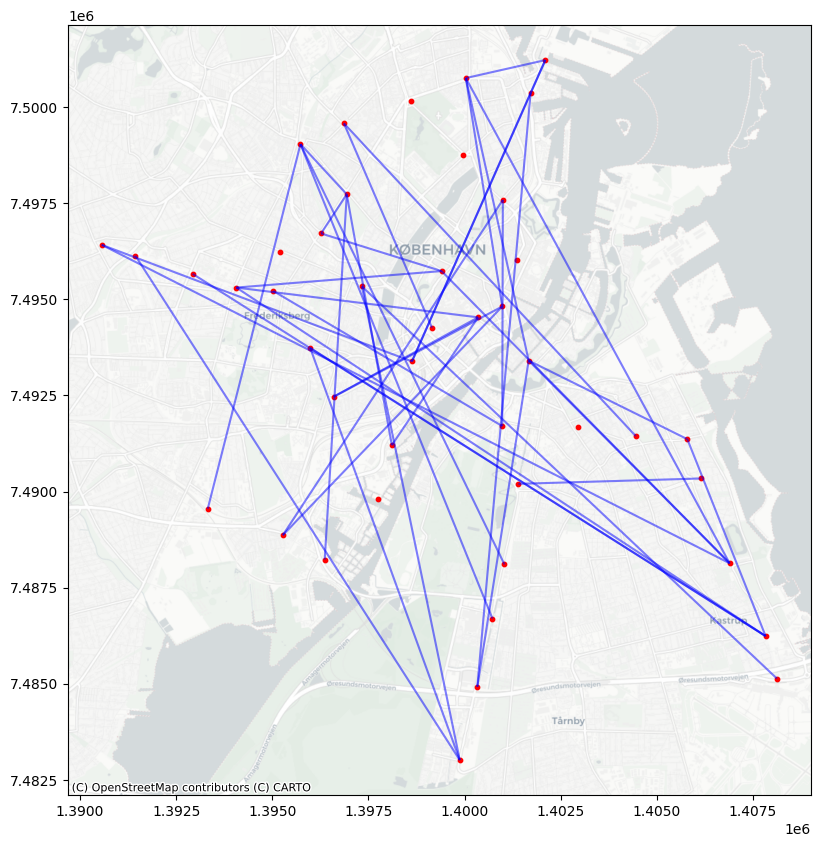

In [8]:
fig, ax = plt.subplots(1,1, figsize = (10,10))
od. plot(ax=ax, color="blue" , alpha=0.5)
gdf_stops_3857.plot(ax=ax, color="red", markersize=10)
cx.add_basemap(ax, source=cx.providers.CartoDB.Positron)

With this setup, I don't like that some nodes are isolated, and it makes no sense to connect nodes with the greatest distance.

Need to implement max distance of teh edge. 
Check along all nodes in that distance(k-neighbours) and then connected to them. 

In [9]:
def knn_edges_projected(gdf, id_col="stop_id", k=3, max_dist=None):
    """
    gdf: GeoDataFrame with Point geometry in a projected CRS (meters).
    max_dist: meters (optional). If set, drop neighbors farther than max_dist.
    Returns: DataFrame of edges (u, v, dist_m)
    """
    if gdf.crs is None:
        raise ValueError("gdf.crs is None. Set CRS before running kNN.")

    # If CRS is geographic (lat/lon), distances won't be meters → reproject
    gdf_utm = gdf.to_crs(gdf.estimate_utm_crs())

    gdf = gdf_utm[[id_col, "geometry"]].dropna().reset_index(drop=True)
    
    print(gdf.head())
    
    # coordinates in meters
    xs = gdf.geometry.x.to_numpy()
    ys = gdf.geometry.y.to_numpy()

    sindex = gdf.sindex
    edges = []

    for i, (u, x, y, geom) in enumerate(zip(gdf[id_col], xs, ys, gdf.geometry)):
        # Expand search window until we have enough candidates
        # (simple heuristic; works well for metro-scale datasets)
        r = 200.0  # start radius (m)
        cand_idx = []
        while len(cand_idx) < (k + 1):  # +1 includes itself
            bbox = (x - r, y - r, x + r, y + r)
            cand_idx = list(sindex.intersection(bbox))
            r *= 2
            if r > 50000:  # safety stop
                break

        # Compute distances to candidates
        dx = xs[cand_idx] - x
        dy = ys[cand_idx] - y
        d = np.hypot(dx, dy)

        # Sort by distance, skip itself
        order = np.argsort(d)
        picked = []
        for idx_in_list in order:
            j = cand_idx[idx_in_list]
            if j == i:
                continue
            dist_m = float(d[idx_in_list])
            if (max_dist is not None) and (dist_m > max_dist):
                continue
            picked.append((i, j, dist_m))
            if len(picked) >= k:
                break

        for _, j, dist_m in picked:
            v = gdf.loc[j, id_col]
            # undirected unique edge
            a, b = sorted((u, v))
            edges.append((a, b, dist_m))

    return pd.DataFrame(edges, columns=["u", "v", "dist_m"]).drop_duplicates()

edges_new = knn_edges_projected(gdf_stops_3857, id_col="stop_id", k=2, max_dist=1350)
print(edges_new.head())



   stop_id                        geometry
0  8603317  POINT (347310.264 6166387.238)
1  8603315  POINT (347605.405 6167453.405)
2  8603312    POINT (348066.915 6169235.6)
3  8603313  POINT (347863.034 6168446.486)
4  8603310  POINT (348105.355 6171264.121)
         u        v       dist_m
0  8603315  8603317  1106.264502
1  8603313  8603315  1025.954324
3  8603312  8603313   815.026663
4  8603311  8603312  1199.284699
7  8603310  8603311   879.704177


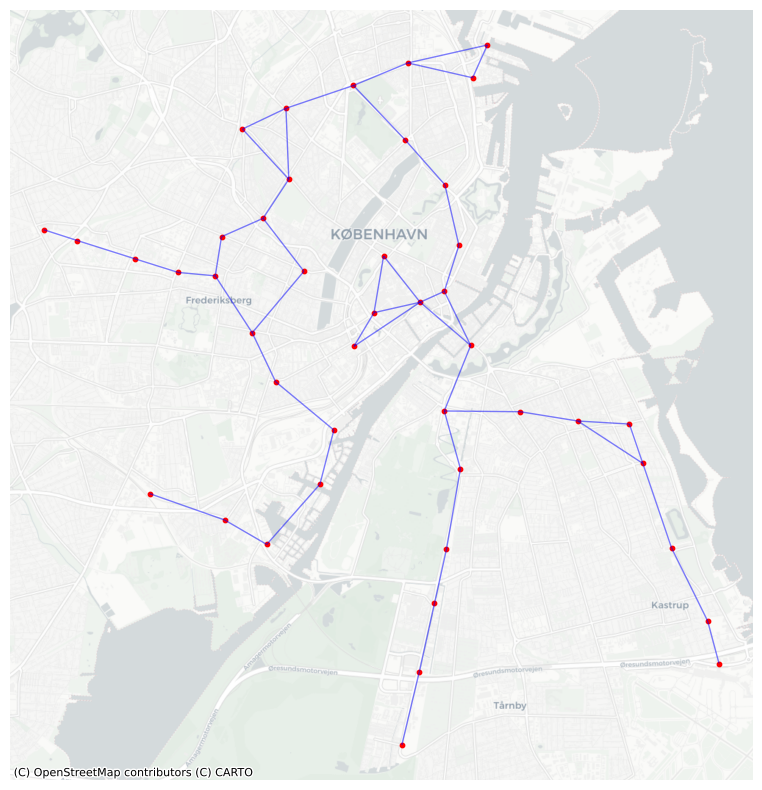

In [10]:
stops_plot = gdf_stops_3857.set_index("stop_id")

def make_line(row):
    p1 = stops_plot.loc[row["u"], "geometry"]
    p2 = stops_plot.loc[row["v"], "geometry"]
    return LineString([p1, p2])

edges_gdf_new = gpd.GeoDataFrame(
    edges_new.copy(),
    geometry=edges_new.apply(make_line, axis=1),
    crs=gdf_stops_3857.crs
)

fig, ax = plt.subplots(1, 1, figsize=(10, 10))

edges_gdf_new.plot(ax=ax, color="blue", alpha=0.5, linewidth=1)
gdf_stops_3857.plot(ax=ax, color="red", markersize=10)

cx.add_basemap(ax, source=cx.providers.CartoDB.Positron, crs=gdf_stops_3857.crs)

ax.set_axis_off()
ax.set_aspect("equal")
plt.show()

**Generate graph with NetworkX**


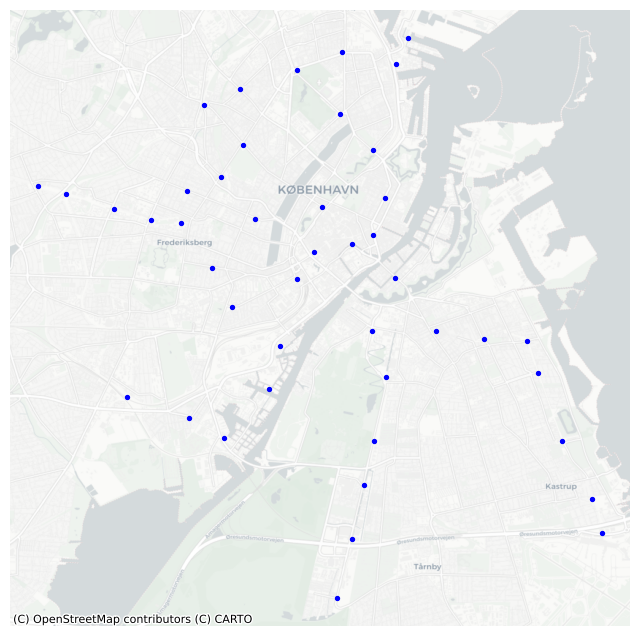

In [11]:
G = nx.Graph()
for name, row in gdf_stops_3857.iterrows():
    G.add_node(row["stop_name"], lat=row["stop_lat"], lon=row["stop_lon"])

pos = {name: (geom.x, geom.y) for name, geom in zip(gdf_stops_3857["stop_name"], gdf_stops_3857.geometry)}

fig, ax = plt.subplots(figsize=(8,8))

nx.draw(G, pos,
        node_size=8,
        edge_color="gray",
        node_color="blue",
        ax=ax,
        with_labels=False)

cx.add_basemap(ax, source=cx.providers.CartoDB.Positron)

ax.set_axis_off()
plt.show()

Parameters:

- max_routes = 4 , the amount of metro lines
- max_stops = 17 (red line), so the metro line is not longer than actual one
- max_distance , distance between stops 
- 

In [22]:
from itertools import combinations

dict_nodes = {}

gdf_utm = gdf_stops_3857.to_crs(gdf_stops_3857.estimate_utm_crs())
gdf = gdf_utm[["stop_name", "geometry"]].dropna().reset_index(drop=True)

dict_node = {
    row.stop_name: {"x": row.geometry.x, "y": row.geometry.y}
    for _, row in gdf.iterrows()
}

print(dict_node)

pair_dictionary = {}


for i, j in combinations(dict_node.keys(), 2):
    dx = dict_node[i]["x"] - dict_node[j]["x"]
    dy = dict_node[i]["y"] - dict_node[j]["y"]
    d = np.hypot(dx, dy)
    
    pair_dictionary.setdefault(i, {})[j] = d


# pair_dictionary

{'Vestamager St. (Metro)': {'x': 347310.2644256227, 'y': 6166387.2376485}, 'Ørestad St. (Metro)': {'x': 347605.4049686749, 'y': 6167453.405180991}, 'Sundby St. (Metro)': {'x': 348066.9153315721, 'y': 6169235.599994942}, 'Bella Center St. (Metro)': {'x': 347863.0344463676, 'y': 6168446.485906068}, 'Islands Brygge St. (Metro)': {'x': 348105.3552270056, 'y': 6171264.120920831}, 'DR Byen St. (Metro)': {'x': 348313.2024911691, 'y': 6170409.323311364}, 'Kongens Nytorv St. (Metro)': {'x': 348167.12071618123, 'y': 6173017.8150338335}, 'Christianshavn St. (Metro)': {'x': 348526.60938797775, 'y': 6172210.988172715}, 'Forum St. (Metro)': {'x': 346115.76055587607, 'y': 6173383.37661468}, 'Nørreport St. (Metro)': {'x': 347293.62735860783, 'y': 6173567.187381142}, 'Fasanvej St. (Metro)': {'x': 344271.5912137538, 'y': 6173431.940354218}, 'Frederiksberg St. (Metro)': {'x': 344811.47346465127, 'y': 6173363.00346383}, 'Flintholm St. (Metro)': {'x': 342806.5658250925, 'y': 6173952.286304374}, 'Lindevang 

In [ ]:
# filter pair_dictionary to only include pairs with distance <= 1350
# thsi helps to avoid too long connections that are not realistic for a metro network

def within_treshold(threshold, dict_nodes):
    valid_connections = {}
    for node, neighbors in dict_nodes.items():
        for connection, distance_between_stations in neighbors.items():
            if distance_between_stations <= threshold:
                if node in valid_connections:
                    valid_connections[node].append((connection, distance_between_stations))
                else:
                    valid_connections[node] = [(connection, distance_between_stations)]

    return valid_connections

# valid_connections = within_treshold(1350, pair_dictionary)
# valid_connections

{'Vestamager St. (Metro)': [('Ørestad St. (Metro)',
   np.float64(1106.2645015954154))],
 'Ørestad St. (Metro)': [('Bella Center St. (Metro)',
   np.float64(1025.954323689291))],
 'Sundby St. (Metro)': [('Bella Center St. (Metro)',
   np.float64(815.0266625149432)),
  ('DR Byen St. (Metro)', np.float64(1199.284698683579))],
 'Islands Brygge St. (Metro)': [('DR Byen St. (Metro)',
   np.float64(879.7041766246457)),
  ('Christianshavn St. (Metro)', np.float64(1036.3458210584429)),
  ('Amagerbro St. (Metro)', np.float64(1114.6055504828107))],
 'DR Byen St. (Metro)': [('Amagerbro St. (Metro)',
   np.float64(1212.0297356589283))],
 'Kongens Nytorv St. (Metro)': [('Christianshavn St. (Metro)',
   np.float64(883.2902631485271)),
  ('Nørreport St. (Metro)', np.float64(1031.8917684098044)),
  ('Marmorkirken St. (Metro)', np.float64(707.7758080011624)),
  ('Gammel Strand St. (Metro)', np.float64(389.8687812202387)),
  ('Rådhuspladsen St. (Metro)', np.float64(1079.5742316564024))],
 'Christianshav

In [28]:
def neighbore_threshold_and_edge_dist(gdf_stops_3857):
    dict_nodes = {}

    gdf_utm = gdf_stops_3857.to_crs(gdf_stops_3857.estimate_utm_crs())
    gdf = gdf_utm[["stop_name", "geometry"]].dropna().reset_index(drop=True)
    # print(gdf)

    # x, y coordinates compatable to meters - two lists of coordinates
    xs = gdf.geometry.x.to_numpy()
    ys = gdf.geometry.y.to_numpy()

    threshold = 0

    for i, node in gdf.iterrows():
        dict_nodes[node["stop_name"]] = {}
        if len(xs) != len(ys):
            print("xs and ys is not same length")
            break
        
        temp_threshold = float('inf')
        for compare in range(len(xs)):
            if i == compare:
                continue
            dx = xs[i] - xs[compare]
            dy = ys[i] - ys[compare]
            d = np.hypot(dx, dy)
            other_stop = gdf.loc[compare, "stop_name"]
            dict_nodes[node["stop_name"]][other_stop] = d
            if d < temp_threshold:
                temp_threshold = d


        if temp_threshold > threshold:
            threshold = temp_threshold

    return threshold, dict_nodes


#def within_treshold(threshold, dict_nodes):
#    valid_connections = {}
#    for node, neighbors in dict_nodes.items():
#        valid_connections[node] = {} # delete this if the coments are removed
#        for connection, distance_between_stations in neighbors.items():
#            if distance_between_stations <= threshold:
#                valid_connections[node][connection] = distance_between_stations
#
#                #if node in valid_connections:
#                #    valid_connections[node].append(connection)
#                #else:
#                #    valid_connections[node][connection] = distance_between_stations
#
#    return valid_connections
            

In [ ]:
# Parameters
max_routes = 4
max_stops = 17
min_stops = 13
threshold = 1350

_, distance_dict = neighbore_threshold_and_edge_dist(gdf_stops_3857)
valid_connections = within_treshold(threshold, distance_dict)

# generations = {}
# generation_id = 0

all_routes = {}
potential_start = list(G.nodes) # as potential start can be any node

routes = 1
while routes < max_routes+1:
    route_current = []
    start_node = random.choice(potential_start) # select random start node from potential nodes
    route_current.append(start_node)

    while len(route_current) < max_stops:
        curr_node = route_current[-1]
        
        if curr_node in potential_start:
            potential_start.remove(curr_node) # this is not good to remove, we are removing from loist while iterating !!!
        
        poss_neighbors = valid_connections[curr_node]
        #poss_neighbors = [n for n in poss_neighbors if n not in route_current]
        
        lowest_distance = float('inf')
        for i in poss_neighbors:
            # if the node is already visited in the current route, remove it from possible neighbors
            if i[0] in route_current:
                poss_neighbors.remove(i)
            # check the mimimum distance to select the closest neighbor
            if i[1] < lowest_distance:
                lowest_distance = i[1]
                closest_neightbor = i[0]
        
        # if we are in dead end, reverse the route and try to find another neighbor from the last node
        if poss_neighbors == []:
            if len(route_current) < min_stops:
                route_current.reverse()
                curr_node = route_current[-1]
                poss_neighbors = valid_connections[curr_node]
                
                for i in poss_neighbors:
                    if i[0] in route_current:
                        poss_neighbors.remove(i) # this is not good to remove, we are removing from loist while iterating !!!
                    if i[1] < lowest_distance:
                        lowest_distance = i[1]
                        closest_neightbor = i[0]
            else:
                break
            
        #random_neighbor = random.choice(poss_neighbors)
        #break_condition = random.random()
        #if break_condition < :
        #    break
        
        route_current.append(closest_neightbor)

    all_routes[routes] = {}
    all_routes[routes]["nodes"] = route_current

    routes += 1

all_routes

{1: {'nodes': ['Sundby St. (Metro)',
   'DR Byen St. (Metro)',
   'Sundby St. (Metro)',
   'Ørestad St. (Metro)',
   'Bella Center St. (Metro)',
   'Ørestad St. (Metro)',
   'Bella Center St. (Metro)',
   'Sundby St. (Metro)',
   'Bella Center St. (Metro)',
   'DR Byen St. (Metro)',
   'Islands Brygge St. (Metro)',
   'DR Byen St. (Metro)',
   'Islands Brygge St. (Metro)',
   'Christianshavn St. (Metro)',
   'Gammel Strand St. (Metro)',
   'Kongens Nytorv St. (Metro)',
   'Gammel Strand St. (Metro)']},
 2: {'nodes': ['Enghave Brygge St. (Metro)',
   'Sluseholmen St. (Metro)',
   'Enghave Brygge St. (Metro)',
   'Havneholmen St. (Metro)',
   'Enghave Brygge St. (Metro)',
   'Havneholmen St. (Metro)',
   'Enghave Plads St. (Metro)',
   'Havneholmen St. (Metro)',
   'Enghave Plads St. (Metro)',
   'Frederiksberg Allé St. (Metro)',
   'Enghave Plads St. (Metro)',
   'Frederiksberg Allé St. (Metro)',
   'Frederiksberg St. (Metro)',
   'Fasanvej St. (Metro)',
   'Frederiksberg St. (Metro)',


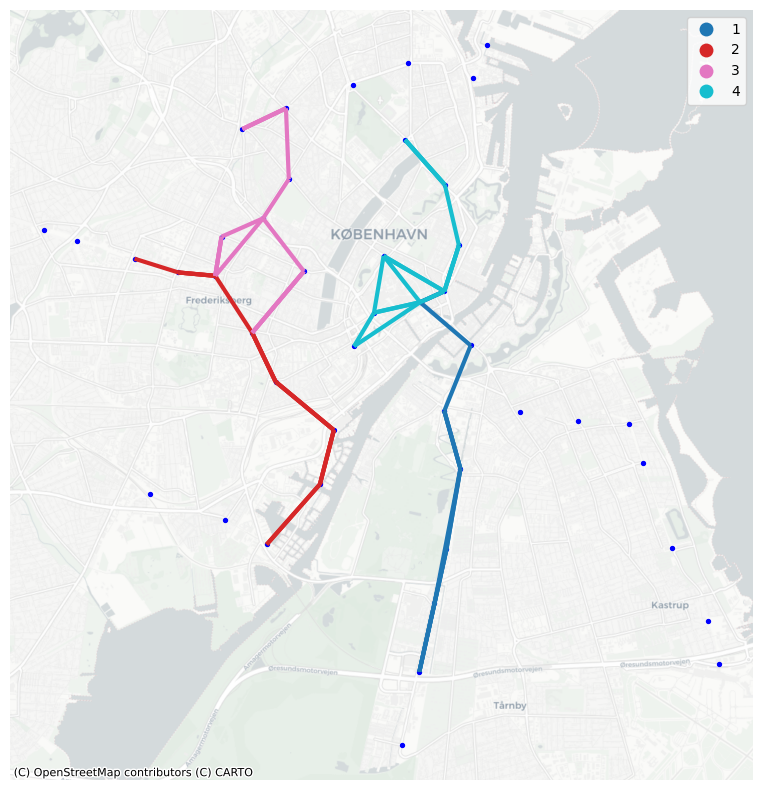

In [48]:
def create_line(p1_name, p2_name, gdf_stops_3857):
    p1 = gdf_stops_3857.loc[gdf_stops_3857["stop_name"] == p1_name, "geometry"].iloc[0]
    p2 = gdf_stops_3857.loc[gdf_stops_3857["stop_name"] == p2_name, "geometry"].iloc[0]
    return LineString([p1, p2])

records = []

for i in all_routes:
    route = all_routes[i]["nodes"]

    for k in range(len(route) - 1):
        p1 = route[k]
        p2 = route[k + 1]
        lines = create_line(p1, p2, gdf_stops_3857)

        records.append({
            "geometry": lines,
            "route_id": i
        })

edges_gdf = gpd.GeoDataFrame(records, crs=gdf_stops_3857.crs)

fig, ax = plt.subplots(1, 1, figsize=(10, 10))

edges_gdf.plot(
    ax=ax,
    column="route_id",     # color by route
    categorical=True,
    legend=True,
    linewidth=3
)

gdf_stops_3857.plot(ax=ax, color="blue", markersize=8)

cx.add_basemap(ax, source=cx.providers.CartoDB.Positron, crs=gdf_stops_3857.crs)

ax.set_axis_off()
ax.set_aspect("equal")
plt.show()


In [41]:
import random

# Parameters
max_routes = 4
max_stops = 17
min_stops = 13
threshold = 1350

_, distance_dict = neighbore_threshold_and_edge_dist(gdf_stops_3857)
valid_connections = within_treshold(threshold, distance_dict)

all_routes = {}
potential_start = list(G.nodes)

used_nodes = set()  # <-- nodes already used in ANY completed route

routes = 1
while routes < max_routes + 1:

    if not potential_start:
        break

    route_current = []
    start_node = random.choice(potential_start)
    route_current.append(start_node)

    while len(route_current) < max_stops:
        curr_node = route_current[-1]

        if curr_node in potential_start:
            potential_start.remove(curr_node)

        if curr_node not in valid_connections:
            break

        # filter out nodes already in this route
        poss_neighbors = [n for n in valid_connections[curr_node] if n[0] not in route_current]

        # dead-end handling
        if not poss_neighbors:
            if len(route_current) < min_stops:
                route_current.reverse()
                curr_node = route_current[-1]

                if curr_node not in valid_connections:
                    break

                poss_neighbors = [n for n in valid_connections[curr_node] if n[0] not in route_current]
                if not poss_neighbors:
                    break
            else:
                break

        # PRIORITIZE nodes not used in any previous route, else shortest distance
        fresh = [t for t in poss_neighbors if t[0] not in used_nodes]
        pick_from = fresh if fresh else poss_neighbors
        next_node = min(pick_from, key=lambda x: x[1])[0]

        route_current.append(next_node)

    all_routes[routes] = {"nodes": route_current}
    used_nodes.update(route_current)  # <-- mark whole route as "used" for future prioritization
    routes += 1

all_routes



{1: {'nodes': ['Vanløse St. (Metro)',
   'Flintholm St. (Metro)',
   'Lindevang St. (Metro)',
   'Fasanvej St. (Metro)',
   'Frederiksberg St. (Metro)',
   'Aksel Møllers Have St. (Metro)',
   'Nuuks Plads St. (Metro)',
   'Nørrebros Runddel St. (Metro)',
   'Nørrebro St. (Metro)',
   'Skjolds Plads St. (Metro)',
   'Vibenshus Runddel St. (Metro)',
   'Poul Henningsens Plads St. (Metro)',
   'Nordhavn St. (Metro)',
   'Orientkaj St. (Metro)']},
 2: {'nodes': ['Vestamager St. (Metro)',
   'Ørestad St. (Metro)',
   'Bella Center St. (Metro)',
   'Sundby St. (Metro)',
   'DR Byen St. (Metro)',
   'Islands Brygge St. (Metro)',
   'Christianshavn St. (Metro)',
   'Kongens Nytorv St. (Metro)',
   'Gammel Strand St. (Metro)',
   'Rådhuspladsen St. (Metro)',
   'København H (Metro)',
   'Havneholmen St. (Metro)',
   'Enghave Brygge St. (Metro)',
   'Sluseholmen St. (Metro)',
   'Mozarts Plads St. (Metro)',
   'København Syd St. (Metro)']},
 3: {'nodes': ['Københavns Lufthavn St. (Metro)',
   '

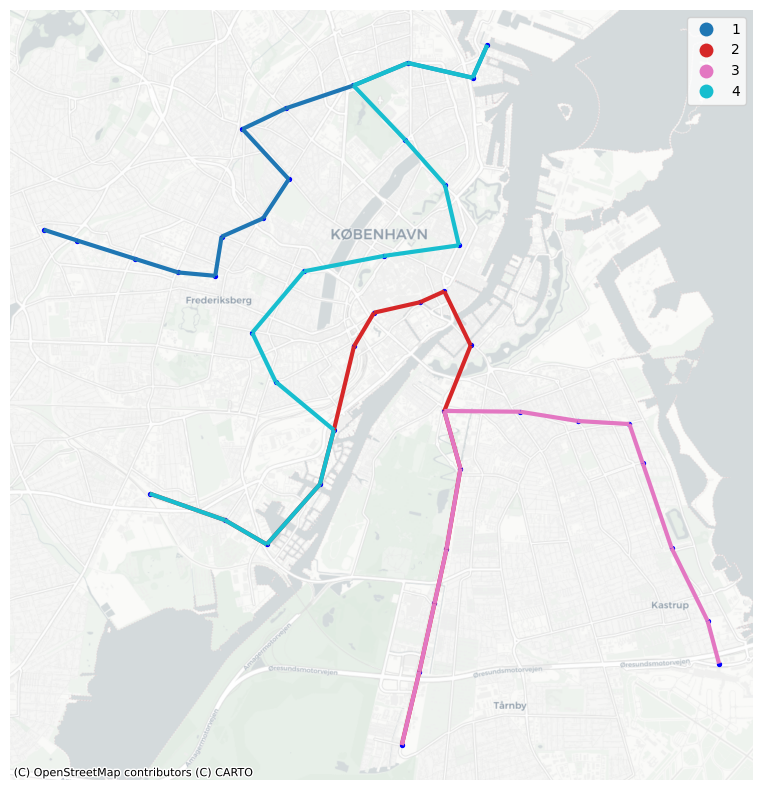

In [ ]:
# a bir transformed code, adding the priority to the not visited nodes

def create_line(p1_name, p2_name, gdf_stops_3857):
    p1 = gdf_stops_3857.loc[gdf_stops_3857["stop_name"] == p1_name, "geometry"].iloc[0]
    p2 = gdf_stops_3857.loc[gdf_stops_3857["stop_name"] == p2_name, "geometry"].iloc[0]
    return LineString([p1, p2])

records = []

for i in all_routes:
    route = all_routes[i]["nodes"]

    for k in range(len(route) - 1):
        p1 = route[k]
        p2 = route[k + 1]
        lines = create_line(p1, p2, gdf_stops_3857)

        records.append({
            "geometry": lines,
            "route_id": i
        })

edges_gdf = gpd.GeoDataFrame(records, crs=gdf_stops_3857.crs)

fig, ax = plt.subplots(1, 1, figsize=(10, 10))

edges_gdf.plot(
    ax=ax,
    column="route_id",     # color by route
    categorical=True,
    legend=True,
    linewidth=3
)

gdf_stops_3857.plot(ax=ax, color="blue", markersize=8)

cx.add_basemap(ax, source=cx.providers.CartoDB.Positron, crs=gdf_stops_3857.crs)

ax.set_axis_off()
ax.set_aspect("equal")
plt.show()
